## Overview Dataframe

In [13]:
from src.io.load_dataset import build_subject_summary

train_summary = build_subject_summary("train")
test_summary = build_subject_summary("test")

train_summary.head()

,subject,localizer_n_epochs,imagine_n_epochs,localizer_shape,imagine_shape,sfreq,n_channels,tmin_localizer,tmax_localizer,tmin_imagine,tmax_imagine
0,sub-02,480,50,"(480, 309, 121)","(50, 309, 521)",100.0,309,-0.2,1.0,-0.2,5.0
1,sub-05,480,50,"(480, 309, 121)","(50, 309, 521)",100.0,309,-0.2,1.0,-0.2,5.0
2,sub-06,480,50,"(480, 309, 121)","(50, 309, 521)",100.0,309,-0.2,1.0,-0.2,5.0
3,sub-07,480,50,"(480, 309, 121)","(50, 309, 521)",100.0,309,-0.2,1.0,-0.2,5.0
4,sub-10,480,50,"(480, 309, 121)","(50, 309, 521)",100.0,309,-0.2,1.0,-0.2,5.0


## One Subject Load

In [14]:
from src.paths import TRAIN_DIR
from src.io.load_subject import load_epochs

subject = "sub-02"
localizer, imagine = load_epochs(TRAIN_DIR / subject, subject)

print(localizer)
print(imagine)

<EpochsFIF | 480 events (all good), -0.2 – 1 s (baseline -0.2 – 0 s), ~143.2 MiB, data loaded,
 'apple': 48
 'bicycle': 48
 'brush': 48
 'cake': 48
 'clown': 48
 'cup': 48
 'desk': 48
 'foot': 48
 'mountain': 48
 'zebra': 48>
<EpochsFIF | 50 events (all good), -0.2 – 5 s (baseline -0.2 – 0 s), ~67.7 MiB, data loaded,
 'apple': 5
 'bicycle': 5
 'brush': 5
 'cake': 5
 'clown': 5
 'cup': 5
 'desk': 5
 'foot': 5
 'mountain': 5
 'zebra': 5>


### Shapes

In [15]:
print(localizer.get_data().shape)
print(imagine.get_data().shape)

(480, 309, 121)
(50, 309, 521)


### Event Labels

In [16]:
print(localizer.event_id)
print(imagine.event_id)

{'apple': 1, 'bicycle': 2, 'brush': 3, 'cake': 4, 'clown': 5, 'cup': 6, 'desk': 7, 'foot': 8, 'mountain': 9, 'zebra': 10}
{'apple': 1, 'bicycle': 2, 'brush': 3, 'cake': 4, 'clown': 5, 'cup': 6, 'desk': 7, 'foot': 8, 'mountain': 9, 'zebra': 10}


### Channel Types

In [17]:
from collections import Counter

Counter(localizer.get_channel_types())

Counter({'grad': 204, 'mag': 102, 'eog': 2, 'ecg': 1})

### Plot Averaged Localizer Response

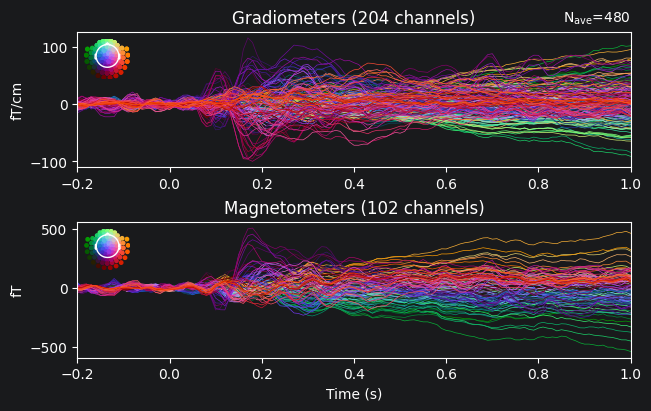

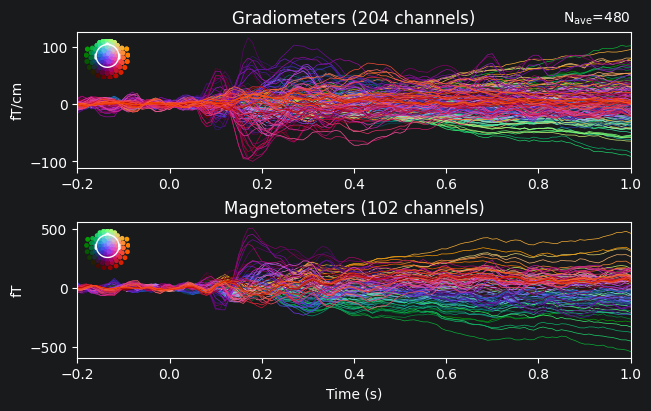

In [18]:
localizer.average().plot()

### Plot Image Class Counts

In [19]:
import pandas as pd

inv_map = {v: k for k, v in localizer.event_id.items()}
y = pd.Series(localizer.events[:, 2]).map(inv_map)
y.value_counts().sort_index()

apple       48
bicycle     48
brush       48
cake        48
clown       48
cup         48
desk        48
foot        48
mountain    48
zebra       48
Name: count, dtype: int64